In [7]:
import pandas as pd


In [8]:
df = pd.read_csv(r"C:\Users\adnan\OneDrive\Desktop\5TH SEM OJT\project 1_diabaties\data\processed\project1_diabetes_cleaned.csv",parse_dates=['last_checkup_date'])

In [9]:
df.head(10)

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome
0,P00826,79,male,0,124.0,71.0,30.000000,134.67525,23.4,0.588,NaN,NO,2023-04-20,0
1,P00108,37,male,0,153.0,85.0,24.000000,42.00000,33.9,0.192,Medium,YES,2024-05-03,1
2,P00517,39,female,0,142.0,68.0,22.000000,159.00000,26.9,0.777,Low,NaN,2023-07-08,0
3,P00687,68,female,7,121.0,88.0,26.406623,134.67525,29.0,1.217,NaN,YES,2024-04-14,1
4,P00927,75,female,0,107.0,84.0,31.000000,101.00000,21.2,0.278,Low,NO,2024-01-27,0
5,P00755,37,female,0,145.0,80.0,26.406623,134.67525,22.0,0.488,High,YES,2024-01-10,0
6,P00431,58,male,5,95.0,72.0,26.406623,170.00000,27.2,0.197,High,NO,2023-12-25,0
7,P00542,58,female,3,150.0,68.0,17.000000,134.67525,46.0,0.808,Medium,NO,2024-06-20,1
8,P00929,32,female,6,129.0,74.0,26.406623,226.00000,20.6,0.655,High,NaN,2023-10-15,1
9,P00513,61,female,0,161.0,77.0,35.000000,201.00000,35.0,1.229,Medium,YES,2023-12-22,1


In [10]:
df.dtypes

patient_id                      str
age                           int64
gender                          str
pregnancies                   int64
glucose                     float64
blood_pressure              float64
skin_thickness              float64
insulin                     float64
bmi                         float64
diabetes_pedigree           float64
physical_activity               str
smoker                          str
last_checkup_date    datetime64[us]
outcome                       int64
dtype: object

create an age-band feature 

In [11]:
df['age_band']=pd.cut( df['age'], bins=[0, 35, 55, 120] , labels=('Young','Middle-Aged','Old'))


In [12]:
df.head(10)

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome,age_band
0,P00826,79,male,0,124.0,71.0,30.000000,134.67525,23.4,0.588,NaN,NO,2023-04-20,0,Old
1,P00108,37,male,0,153.0,85.0,24.000000,42.00000,33.9,0.192,Medium,YES,2024-05-03,1,Middle-Aged
2,P00517,39,female,0,142.0,68.0,22.000000,159.00000,26.9,0.777,Low,NaN,2023-07-08,0,Middle-Aged
3,P00687,68,female,7,121.0,88.0,26.406623,134.67525,29.0,1.217,NaN,YES,2024-04-14,1,Old
4,P00927,75,female,0,107.0,84.0,31.000000,101.00000,21.2,0.278,Low,NO,2024-01-27,0,Old
5,P00755,37,female,0,145.0,80.0,26.406623,134.67525,22.0,0.488,High,YES,2024-01-10,0,Middle-Aged
6,P00431,58,male,5,95.0,72.0,26.406623,170.00000,27.2,0.197,High,NO,2023-12-25,0,Old
7,P00542,58,female,3,150.0,68.0,17.000000,134.67525,46.0,0.808,Medium,NO,2024-06-20,1,Old
8,P00929,32,female,6,129.0,74.0,26.406623,226.00000,20.6,0.655,High,NaN,2023-10-15,1,Young
9,P00513,61,female,0,161.0,77.0,35.000000,201.00000,35.0,1.229,Medium,YES,2023-12-22,1,Old


In [13]:
 df['age_band'].value_counts()

age_band
Old            372
Middle-Aged    326
Young          252
Name: count, dtype: int64

create a BMI category feature

In [14]:
df['bmi_band']=pd.cut( df['bmi'], bins=[0, 18.5, 25, 30, 100] , labels=('Underweight','Normal','Overweight','Obese'))

In [15]:
df['bmi_band'].value_counts()

bmi_band
Obese          553
Overweight     235
Normal         124
Underweight     38
Name: count, dtype: int64

create a glucose band features

In [16]:
df['glucose_band']=pd.cut( df['glucose'], bins=[0, 100, 126, 300] , labels=('Normal','Prediabetes','Diabetes'))

In [17]:
df['glucose_band'].value_counts()

glucose_band
Diabetes       349
Prediabetes    337
Normal         264
Name: count, dtype: int64

create an insulin to glucose ration feature

In [18]:
df['insulin_glucose']=df['insulin'] / df['glucose']

In [19]:
df.head(10)

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome,age_band,bmi_band,glucose_band,insulin_glucose
0,P00826,79,male,0,124.0,71.0,30.000000,134.67525,23.4,0.588,NaN,NO,2023-04-20,0,Old,Normal,Prediabetes,1.086091
1,P00108,37,male,0,153.0,85.0,24.000000,42.00000,33.9,0.192,Medium,YES,2024-05-03,1,Middle-Aged,Obese,Diabetes,0.274510
2,P00517,39,female,0,142.0,68.0,22.000000,159.00000,26.9,0.777,Low,NaN,2023-07-08,0,Middle-Aged,Overweight,Diabetes,1.119718
3,P00687,68,female,7,121.0,88.0,26.406623,134.67525,29.0,1.217,NaN,YES,2024-04-14,1,Old,Overweight,Prediabetes,1.113019
4,P00927,75,female,0,107.0,84.0,31.000000,101.00000,21.2,0.278,Low,NO,2024-01-27,0,Old,Normal,Prediabetes,0.943925
5,P00755,37,female,0,145.0,80.0,26.406623,134.67525,22.0,0.488,High,YES,2024-01-10,0,Middle-Aged,Normal,Diabetes,0.928795
6,P00431,58,male,5,95.0,72.0,26.406623,170.00000,27.2,0.197,High,NO,2023-12-25,0,Old,Overweight,Normal,1.789474
7,P00542,58,female,3,150.0,68.0,17.000000,134.67525,46.0,0.808,Medium,NO,2024-06-20,1,Old,Obese,Diabetes,0.897835
8,P00929,32,female,6,129.0,74.0,26.406623,226.00000,20.6,0.655,High,NaN,2023-10-15,1,Young,Normal,Diabetes,1.751938
9,P00513,61,female,0,161.0,77.0,35.000000,201.00000,35.0,1.229,Medium,YES,2023-12-22,1,Old,Obese,Diabetes,1.248447


check if there is any imposible value in the ratio

In [20]:
df['insulin_glucose'].describe()

count    950.000000
mean       1.239975
std        1.180040
min        0.054348
25%        0.746259
50%        1.115991
75%        1.550670
max       22.745763
Name: insulin_glucose, dtype: float64

In [21]:
import numpy as np

np.isinf is used check for infinte value

In [22]:
np.isinf(df['insulin_glucose']).sum()

np.int64(0)

create a pregnanices-per-year-of-age feature

In [23]:
df['pregnancies_rate']=df['pregnancies'] / df['age']

In [24]:
df['pregnancies_rate'].head(10)

0    0.000000
1    0.000000
2    0.000000
3    0.102941
4    0.000000
5    0.000000
6    0.086207
7    0.051724
8    0.187500
9    0.000000
Name: pregnancies_rate, dtype: float64

In [25]:
df['pregnancies_rate'].describe()

count    950.000000
mean       0.042795
std        0.067448
min        0.000000
25%        0.000000
50%        0.000000
75%        0.072661
max        0.380952
Name: pregnancies_rate, dtype: float64

create a days-since lastcheckup date feature

In [26]:
reference_date=df['last_checkup_date'].max()                                     

In [27]:
reference_date


Timestamp('2024-12-28 00:00:00')

In [28]:
df['since_checkup'] = (reference_date - df['last_checkup_date']).dt.days

In [29]:
df['since_checkup'].head(10)

0    618
1    239
2    539
3    258
4    336
5    353
6    369
7    191
8    440
9    372
Name: since_checkup, dtype: int64

create a categorical combination feature

In [30]:
df['activity_smoker']= df['physical_activity'] +'/'+ df['smoker']

In [31]:
df['activity_smoker'].head(10)

0           NaN
1    Medium/YES
2           NaN
3           NaN
4        Low/NO
5      High/YES
6       High/NO
7     Medium/NO
8           NaN
9    Medium/YES
Name: activity_smoker, dtype: str

check the combination features balance


In [32]:
df['activity_smoker'].value_counts()

activity_smoker
Medium/NO     207
High/NO       195
Low/NO        180
Low/YES        93
Medium/YES     90
High/YES       85
Name: count, dtype: int64

list every new inventory column

In [33]:
# activity_smoker = physical + smoker 
# since_checkup = reference - last_checkup_date
# pregnancies_rate = pregnency/age
# insulin_glucose = insulin/glucose
# glucose_band = glucose
# bmi_category = bmi
# age_band = age

In [34]:
df.shape

(950, 21)

# EXPLORATORY ANALYSIS

re-rum the group comparison on original features

In [35]:
numeric_cols=['age','pregnancies','glucose','blood_pressure','skin_thickness','insulin','bmi','diabetes_pedigree']
df.groupby('outcome')[numeric_cols].mean()

,age,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree
outcome,,,,,,,,
0,47.861152,1.828656,112.220027,72.356897,26.458444,134.407565,30.959786,0.441821
1,54.798535,1.915751,131.868081,71.936873,26.141455,135.477453,32.533568,0.511564


In [36]:
engineering_numeric=['insulin_glucose','pregnancies_rate','since_checkup']
df.groupby('outcome')[engineering_numeric].mean()

,insulin_glucose,pregnancies_rate,since_checkup
outcome,,,
0,1.298950,0.044402,350.304284
1,1.093728,0.038809,366.534799


In [37]:
#T=transporse-swapping rows and columns , abs()=absolute-make sure it only give positive vlue
group_means=df.groupby('outcome')[numeric_cols + engineering_numeric].mean().T
group_means['gap']=(group_means[1]-group_means[0]).abs()
group_means.sort_values('gap',ascending=False)

outcome,0,1,gap
glucose,112.220027,131.868081,19.648054
since_checkup,350.304284,366.534799,16.230515
age,47.861152,54.798535,6.937383
bmi,30.959786,32.533568,1.573782
insulin,134.407565,135.477453,1.069889
blood_pressure,72.356897,71.936873,0.420025
skin_thickness,26.458444,26.141455,0.316989
insulin_glucose,1.298950,1.093728,0.205222
pregnancies,1.828656,1.915751,0.087095
diabetes_pedigree,0.441821,0.511564,0.069743


state the new top three

In [38]:
#1-glucose
#2-since_checkup
#3-age

cross tabulate the age band agints outcome

In [39]:
pd.crosstab(df['age_band'],df['outcome'],normalize='index')

outcome,0,1
age_band,,
Young,0.789683,0.210317
Middle-Aged,0.766871,0.233129
Old,0.612903,0.387097


cross tabulate the bmi agints outcome

In [40]:
pd.crosstab(df['bmi_band'],df['outcome'],normalize='index')

outcome,0,1
bmi_band,,
Underweight,0.763158,0.236842
Normal,0.750000,0.250000
Overweight,0.770213,0.229787
Obese,0.676311,0.323689


cross-tabulate the glucose against outcome

In [41]:
pd.crosstab(df['glucose_band'],df['outcome'],normalize='index')

outcome,0,1
glucose_band,,
Normal,0.901515,0.098485
Prediabetes,0.715134,0.284866
Diabetes,0.567335,0.432665


chart the clearest pattern

In [42]:
import matplotlib.pyplot as plt

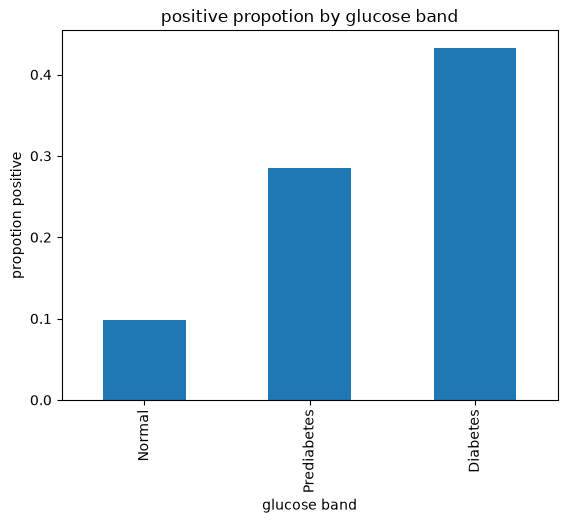

In [43]:
ax = pd.crosstab(df['glucose_band'],df['outcome'],normalize ='index')[1].plot(kind = 'bar')
ax.set_xlabel("glucose band")
ax.set_ylabel("propotion positive")
ax.set_title("positive propotion by glucose band")
plt.show()

In [44]:
df.to_csv(r"C:\Users\adnan\OneDrive\Desktop\5TH SEM OJT\project 1_diabaties\data\processed\mohammed_adnan_p1w2_features.csv",index=False)

In [46]:
df=pd.read_csv(r"C:\Users\adnan\OneDrive\Desktop\5TH SEM OJT\project 1_diabaties\data\processed\mohammed_adnan_p1w2_features.csv")

In [47]:
df.head()

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,...,smoker,last_checkup_date,outcome,age_band,bmi_band,glucose_band,insulin_glucose,pregnancies_rate,since_checkup,activity_smoker
0,P00826,79,male,0,124.0,71.0,30.000000,134.67525,23.4,0.588,...,NO,2023-04-20,0,Old,Normal,Prediabetes,1.086091,0.000000,618,NaN
1,P00108,37,male,0,153.0,85.0,24.000000,42.00000,33.9,0.192,...,YES,2024-05-03,1,Middle-Aged,Obese,Diabetes,0.274510,0.000000,239,Medium/YES
2,P00517,39,female,0,142.0,68.0,22.000000,159.00000,26.9,0.777,...,NaN,2023-07-08,0,Middle-Aged,Overweight,Diabetes,1.119718,0.000000,539,NaN
3,P00687,68,female,7,121.0,88.0,26.406623,134.67525,29.0,1.217,...,YES,2024-04-14,1,Old,Overweight,Prediabetes,1.113019,0.102941,258,NaN
4,P00927,75,female,0,107.0,84.0,31.000000,101.00000,21.2,0.278,...,NO,2024-01-27,0,Old,Normal,Prediabetes,0.943925,0.000000,336,Low/NO
